# 📈 Stock Price Time Series Analysis

## 📌 Objective
Analyze stock price trends over time, detect seasonality, and explore patterns.

## 🛠 Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [8]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vishardmehta/faang-stock-market-data-with-technical-indicators/faang_stock_prices.csv


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('/kaggle/input/datasets/vishardmehta/faang-stock-market-data-with-technical-indicators/faang_stock_prices.csv')

df.head()

,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239


## 📊 Dataset Overview

The dataset contains:
- Stock prices
- Trading volume
- Technical indicators
- Daily returns
- Volatility metrics

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14964 entries, 0 to 14963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             14964 non-null  object 
 1   Ticker           14964 non-null  object 
 2   Open             14964 non-null  float64
 3   High             14964 non-null  float64
 4   Low              14964 non-null  float64
 5   Close            14964 non-null  float64
 6   Volume           14964 non-null  int64  
 7   SMA_7            14964 non-null  float64
 8   SMA_21           14964 non-null  float64
 9   EMA_12           14964 non-null  float64
 10  EMA_26           14964 non-null  float64
 11  RSI_14           14964 non-null  float64
 12  MACD             14964 non-null  float64
 13  MACD_Signal      14964 non-null  float64
 14  Bollinger_Upper  14964 non-null  float64
 15  Bollinger_Lower  14964 non-null  float64
 16  Daily_Return     14964 non-null  float64
 17  Volatility_7

## 🧹 Data Preprocessing

We convert the date column into datetime format
and prepare the dataset for time series analysis.

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

# Sort values
df = df.sort_values('Date')

## 🏢 Company Selection

We focus on Apple stock for detailed analysis.

In [13]:
apple = df[df['Ticker'] == 'AAPL']

## 📈 Closing Price Trend

Analyze how stock prices changed over time.

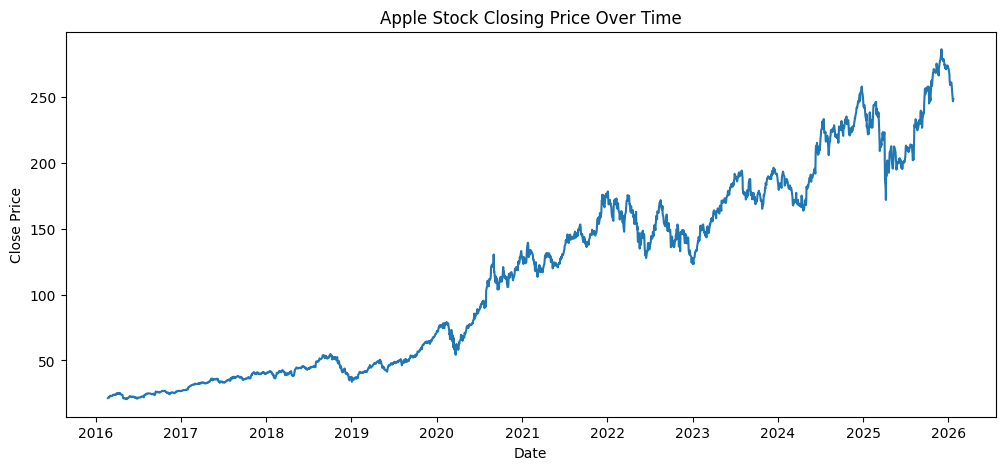

In [16]:
plt.figure(figsize=(12,5))

plt.plot(apple['Date'], apple['Close'])

plt.title("Apple Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

## 📊 Moving Average Analysis

Moving averages smooth short-term fluctuations
and reveal long-term trends.

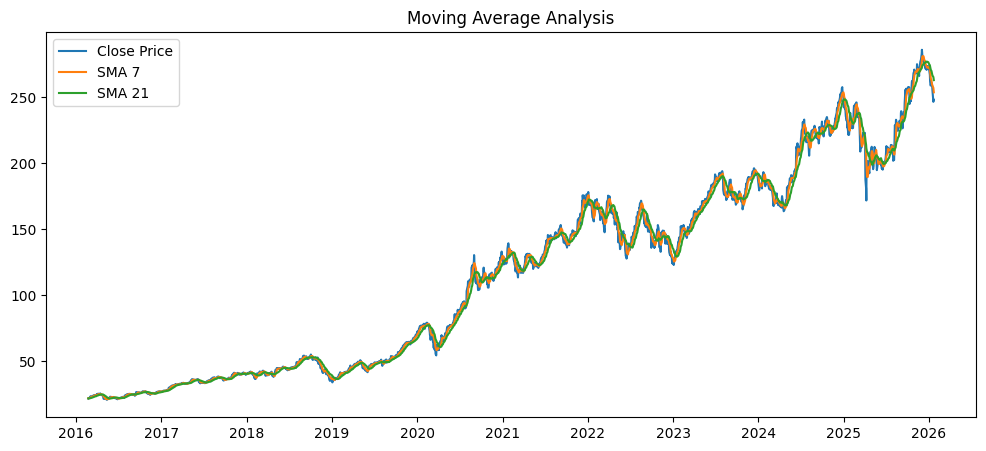

In [17]:
plt.figure(figsize=(12,5))

plt.plot(apple['Date'], apple['Close'], label='Close Price')
plt.plot(apple['Date'], apple['SMA_7'], label='SMA 7')
plt.plot(apple['Date'], apple['SMA_21'], label='SMA 21')

plt.legend()

plt.title("Moving Average Analysis")
plt.show()

## 📉 RSI Analysis

RSI (Relative Strength Index) helps identify
overbought and oversold market conditions.

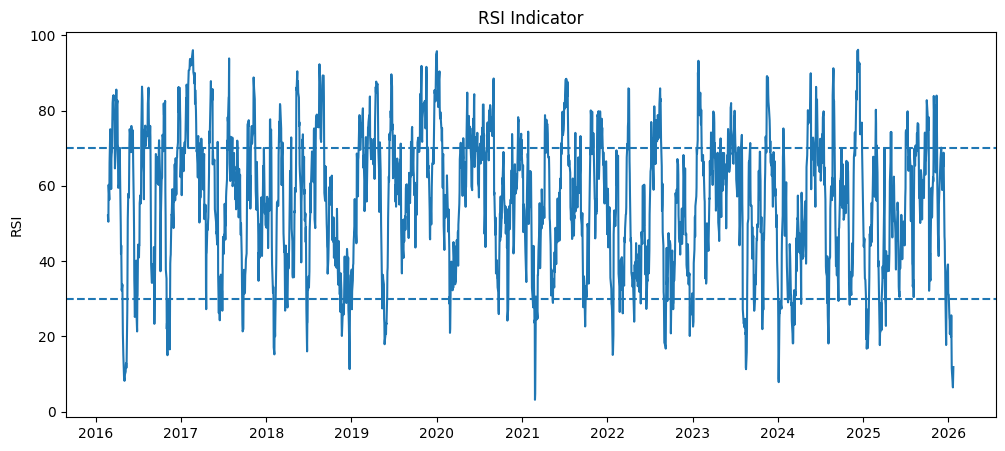

In [18]:
plt.figure(figsize=(12,5))

plt.plot(apple['Date'], apple['RSI_14'])

plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title("RSI Indicator")
plt.ylabel("RSI")

plt.show()

## 📈 MACD Analysis

MACD helps identify momentum and trend direction.

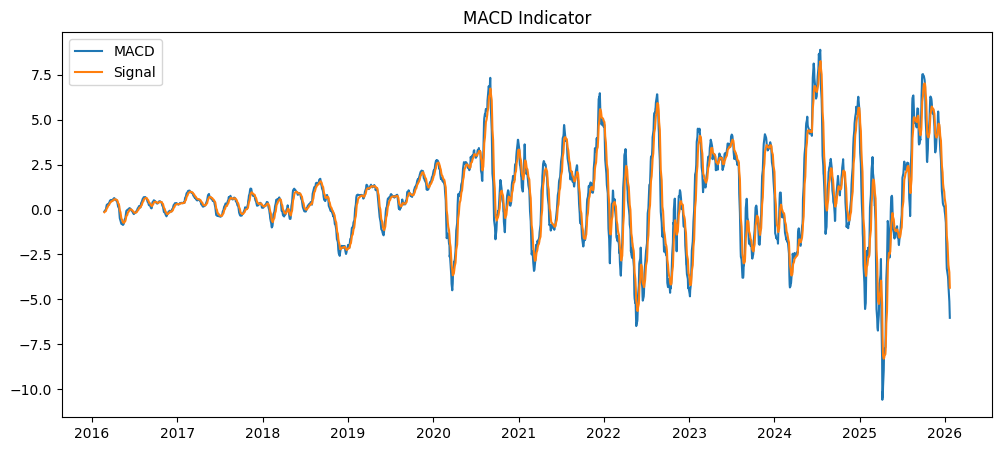

In [19]:
plt.figure(figsize=(12,5))

plt.plot(apple['Date'], apple['MACD'], label='MACD')
plt.plot(apple['Date'], apple['MACD_Signal'], label='Signal')

plt.legend()

plt.title("MACD Indicator")
plt.show()

## ⚡ Volatility Analysis

Volatility measures price fluctuations and market risk.

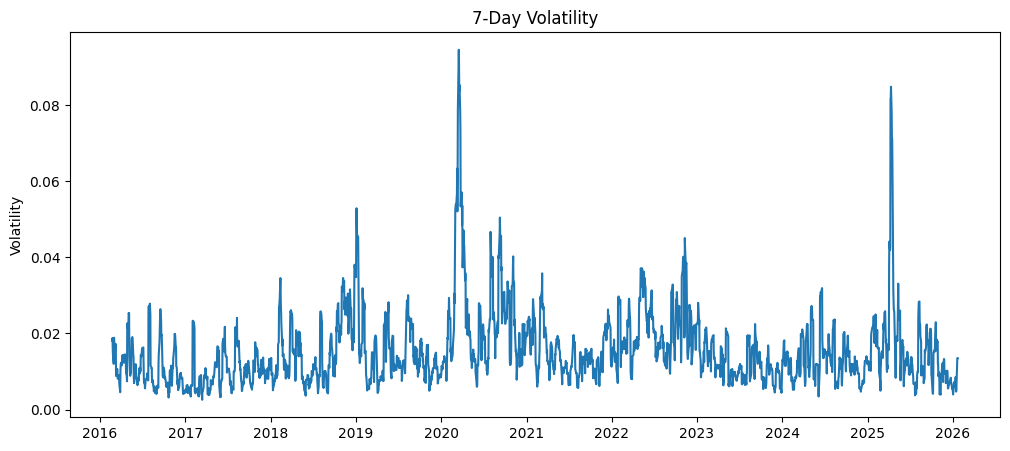

In [20]:
plt.figure(figsize=(12,5))

plt.plot(apple['Date'], apple['Volatility_7d'])

plt.title("7-Day Volatility")
plt.ylabel("Volatility")

plt.show()

## 🔮 Forecasting Future Prices

Using Linear Regression for basic future trend prediction.

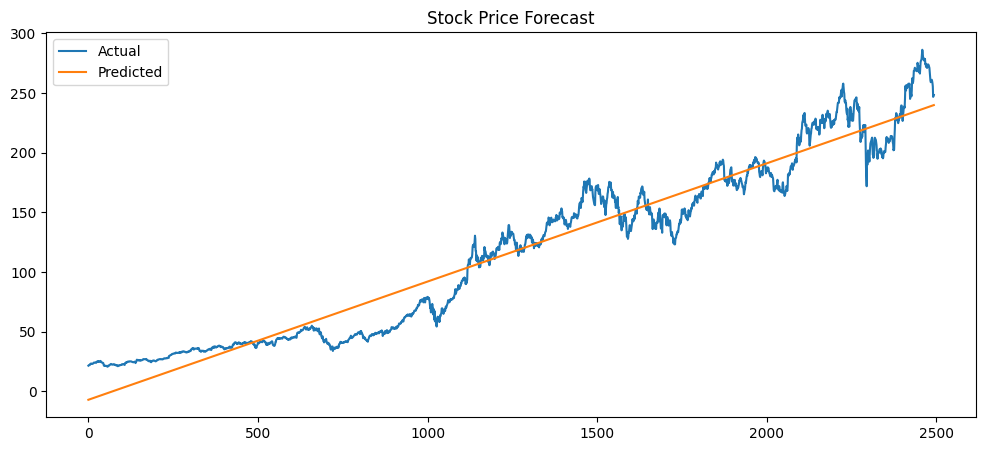

In [21]:
from sklearn.linear_model import LinearRegression
import numpy as np

apple = apple.reset_index(drop=True)

apple['Day'] = np.arange(len(apple))

X = apple[['Day']]
y = apple['Close']

model = LinearRegression()
model.fit(X, y)

apple['Prediction'] = model.predict(X)

plt.figure(figsize=(12,5))

plt.plot(apple['Close'], label='Actual')
plt.plot(apple['Prediction'], label='Predicted')

plt.legend()

plt.title("Stock Price Forecast")

plt.show()

##### 🔍 Key Insights & Conclusion

## 📈 Closing Price Trend Analysis
- Apple stock showed a strong long-term upward trend from 2016 to 2025.
- Stock prices increased significantly over the years, reflecting strong investor confidence and company growth.
- Although temporary market corrections occurred, the overall trend remained bullish.

---

## 📊 Moving Average Analysis
- The 7-day and 21-day moving averages successfully smoothed short-term fluctuations.
- SMA 7 reacted faster to price movements, while SMA 21 represented long-term direction.
- Multiple crossover points indicated changes in market momentum and possible trend reversals.

---

## 📉 RSI (Relative Strength Index) Analysis
- RSI frequently crossed the overbought (70) and oversold (30) levels.
- These movements indicated periods of strong buying and selling pressure in the market.
- The RSI indicator highlighted several potential trading opportunities during volatile phases.

---

## 📈 MACD Indicator Analysis
- MACD and Signal line crossovers reflected multiple bullish and bearish momentum shifts.
- Positive MACD values indicated upward momentum, while negative values reflected bearish trends.
- The indicator effectively captured market trend changes during volatile periods.

---

## ⚡ Volatility Analysis
- Significant volatility spikes were observed during uncertain market conditions.
- High volatility periods indicated increased risk and rapid price fluctuations.
- Most periods maintained moderate volatility, suggesting relatively stable long-term growth.

---

## 🔮 Forecasting Analysis
- The Linear Regression forecasting model captured the overall upward trend of Apple stock.
- However, sudden price spikes and sharp market fluctuations were not fully predicted.
- This suggests that stock prices are nonlinear and influenced by multiple external factors.

---

# 🧠 Final Conclusion

This project successfully demonstrated how Time Series Analysis can be used to:
- Identify long-term market trends
- Analyze momentum using technical indicators
- Detect volatility and market uncertainty
- Perform basic stock price forecasting

Overall, Apple stock displayed strong long-term growth with periodic fluctuations and volatility spikes during uncertain market conditions. Technical indicators such as Moving Averages, RSI, and MACD provided valuable insights into market behavior and trading momentum.